## Import

In [1]:
# Import necessary libraries
from pyhgf.model import Network
from scipy.stats import halfnorm, norm
import copy
import pandas as pd
import time
import numpy as np
from voting import get_votes,generate_observations,generate_candidates,individual_vote
import altair as alt
import matplotlib.pyplot as plt
import colorsys
import altair as alt
import jax.numpy as jnp
import pandas as pd
import altair as alt

# Import JAX and related modules
from jax import jit
from jax import random, vmap
from jax.tree_util import Partial
from functools import partial as Partial

# Round one
https://en.wikipedia.org/wiki/Quadratic_voting
https://en.wikipedia.org/wiki/Ranked_voting#Theoretical_foundations_of_ranked_voting

## Parameters

In [ ]:
# Parameters for the simulation
n_candidates = 12 
n_preferences = 10
n_agents = 100_000  
voting_system = "basic" # "basic", "ranked", "quadratic"

# Generate observations using the generate_observations function
input_data = generate_observations(n_nodes=n_preferences, n_steps=100, scenario=1)

# Generate tonic volatilities for agents using a normal distribution
tonic_volatilities = np.random.normal(-3.0, 1.0, n_agents)

# Generate candidate
candidate_list = generate_candidates(n_candidates=n_candidates, n_preferences=n_preferences)

mask = np.ones(n_candidates)


## Agents

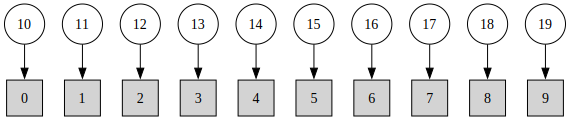

In [15]:
# Create agent preferences dynamically based on n_preferences
network = Network()

# Add binary-state nodes to the network
network.add_nodes(kind="binary-state", n_nodes=n_preferences)

# Add value nodes for each binary-state node
for i in range(n_preferences):
    network.add_nodes(value_children=i)

# Plot the network
network.plot_network()

In [16]:
# Setup and vectorize the get_votes function for the first round
get_votes_fn = Partial(
    individual_vote,
    network=network,
    candidates=candidate_list,
    n_preferences=n_preferences,
    input_data=input_data,
    mask=mask,
    voting_system=voting_system
)
vmap_get_votes_fn = vmap(get_votes_fn)
key = random.PRNGKey(int(time.time()))
keys = random.split(key, n_agents)
votes = vmap_get_votes_fn(tonic_volatilities, keys)

# Split into 10 simulations
simulations = np.array_split(votes, 100)

In [18]:
# Prepare a list to store proportions for each simulation
rows = []

for i, sim in enumerate(simulations):
    total_votes = len(sim)
    unique, counts = np.unique(sim, return_counts=True)
    for candidate, count in zip(unique, counts):
        rows.append({
            'simulation_number': i + 1,  # simulation numbers 1–10
            'candidate': candidate,
            'proportion': count / total_votes
        })

# Convert to DataFrame
df_simulations = pd.DataFrame(rows)

# Optional: convert candidate to categorical for Altair
df_simulations['candidate'] = df_simulations['candidate'].astype('category')
df_simulations['candidate_id'] = df_simulations['candidate'].cat.codes

df_simulations

,simulation_number,candidate,proportion,candidate_id
0,1,0.0,11.122,0
1,1,1.0,0.262,1
2,1,2.0,0.030,2
3,1,3.0,0.006,3
4,1,4.0,0.002,4
...,...,...,...,...
6326,100,93.0,0.002,93
6327,100,94.0,0.001,94
6328,100,95.0,0.001,95
6329,100,98.0,0.001,98


In [19]:
# Define a color scale based on all candidates
all_candidates = df_simulations['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Define interactive highlight on mouseover
highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')

# Create area chart
chart = alt.Chart(df_simulations).mark_area(opacity=0.85).encode(
    x=alt.X('simulation_number:N', title='Simulation Number'),
    y=alt.Y('proportion:Q', stack='center', title='Vote Proportion', axis=alt.Axis(format='.0%')),
    color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
    opacity=alt.condition(highlight, alt.value(1), alt.value(0.2)),
    tooltip=[
        alt.Tooltip('candidate:N', title='Candidate'),
        alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
        alt.Tooltip('simulation_number:N', title='Simulation')
    ]
).add_selection(highlight).properties(
    width=1000,
    height=250,
    title="Evolution of Vote Proportions – Simulations"
)

chart

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_30083/737925221.py:6: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use 'selection_point()' or 'selection_interval()' instead.
These functions also include more helpful docstrings.
  highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')
/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_30083/737925221.py:19: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(highlight).properties(


MaxRowsError: The number of rows in your dataset is greater than the maximum allowed (5000).

Try enabling the VegaFusion data transformer which raises this limit by pre-evaluating data
transformations in Python.
    >> import altair as alt
    >> alt.data_transformers.enable("vegafusion")

Or, see https://altair-viz.github.io/user_guide/large_datasets.html for additional information
on how to plot large datasets.

alt.Chart(...)

In [7]:
# identify the winners
winners = (
    df_simulations
    .loc[df_simulations.groupby("simulation_number")["proportion"].idxmax()]
)

# Count the wins
df_wins = winners["candidate_id"].value_counts().reset_index()
df_wins.columns = ["candidate_id", "wins"]

# Define color scale
all_candidates = df_simulations['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Create histogram of wins
hist = (
    alt.Chart(df_wins)
    .mark_bar()
    .encode(
        x=alt.X("candidate_id:N", title="Candidate", sort="-y"),
        y=alt.Y("wins:Q", title="Number of Wins"),
        color=alt.Color("candidate_id:N", scale=color_scale, legend=alt.Legend(title="Candidate")),
        tooltip=["candidate_id:N", "wins:Q"]
    )
    .properties(
        width=600,
        height=400,
        title="Histogram of Candidate Wins Across Simulations"
    )
)

hist

alt.Chart(...)

# Round two

In [8]:
# For each simulation select the two best candidates
best_two_candidates = (
    df_simulations.groupby('simulation_number', group_keys=False)
    .apply(lambda x: x.nlargest(2, 'proportion'))
)
best_two_candidates

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_30083/2205060293.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(2, 'proportion'))


,simulation_number,candidate,proportion,candidate_id
0,1,0,1.0,0
1,1,1,1.0,1
12,2,0,1.0,0
13,2,1,1.0,1
24,3,0,1.0,0
...,...,...,...,...
1165,98,1,1.0,1
1176,99,0,1.0,0
1177,99,1,1.0,1
1188,100,0,1.0,0


In [9]:
# Split tonic volatilities into chunks for second round
tonic_volatilities_chunks = np.array_split(tonic_volatilities, 100)
n_agents = 1000
results = []  # on accumule toutes les simulations ici

for simulation in range(len(simulations)):
    # take two candidates for this simulation
    best_two_candidates = simulations[simulation]

    # build JAX mask (True = keep, False = mask out)
    mask = jnp.zeros(n_candidates, dtype=bool).at[best_two_candidates].set(True)

    tonic_volatilities = tonic_volatilities_chunks[simulation]

    # Setup and vectorize the get_votes function
    get_votes_fn = Partial(
        individual_vote,
        network=network,
        candidates=candidate_list,
        n_preferences=n_preferences,
        input_data=input_data,
        mask=mask,
        voting_system=voting_system
    )
    vmap_get_votes_fn = vmap(get_votes_fn)

    # Random keys for each agent
    key = random.PRNGKey(int(time.time()))
    keys = random.split(key, n_agents)

    # Compute votes
    votes = vmap_get_votes_fn(tonic_volatilities, keys)

    # ---- DataFrame part ----
    # Compter votes par candidat
    unique, counts = np.unique(np.array(votes), return_counts=True)
    proportions = counts / n_agents

    for u, p in zip(unique, proportions):
        results.append({
            "simulation_number": simulation + 1,   # commence à 1
            "candidate": u,                        # index interne
            "proportion": p,
            "candidate_id": candidate_list[u],     # mapping vers ID réel
        })

# DataFrame final
df_votes = pd.DataFrame(results)


In [10]:
df_votes

,simulation_number,candidate,proportion,candidate_id
0,1,0,1.0,"([3.7596114423673868, 1.43815413418396, 2.6890..."
1,1,1,1.0,"([3.915325940642303, 2.9264920223020203, 1.909..."
2,1,2,1.0,"([-0.1851370787110369, 0.3038930054756248, 1.5..."
3,1,3,1.0,"([1.1728656550691903, 2.466970518765821, 1.551..."
4,1,4,1.0,"([1.958922192037964, 2.9902221320571756, 0.781..."
...,...,...,...,...
1195,100,7,1.0,"([0.8330000979125323, 2.7907547371240744, 0.83..."
1196,100,8,1.0,"([1.327017393386895, 4.246810229127847, 2.6910..."
1197,100,9,1.0,"([1.778433228759546, 1.7807345651734767, 3.451..."
1198,100,10,1.0,"([2.2583267556899993, 3.5909979186241174, 0.60..."


In [11]:
# Define color scale
all_candidates = df_simulations['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Define interactive selection (mouseover)
highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')

# Define the chart
chart = (
    alt.Chart(df_simulations)
    .mark_area(opacity=0.85)
    .encode(
        x=alt.X('simulation_number:Q', title='Simulation Number'),
        y=alt.Y(
            'proportion:Q',
            stack='center',  # ou 'normalize' si tu veux 100%
            title='Vote Proportion',
            axis=alt.Axis(format='.0%')
        ),
        color=alt.Color('candidate_id:N', scale=color_scale, legend=alt.Legend(title='Candidate')),
        opacity=alt.condition(highlight, alt.value(1), alt.value(0.2)),
        tooltip=[
            alt.Tooltip('candidate:N', title='Candidate'),
            alt.Tooltip('proportion:Q', title='Proportion', format='.1%'),
            alt.Tooltip('simulation_number:Q', title='Simulation')
        ],
    )
    .add_selection(highlight)
    .properties(
        width=1000,
        height=400,
        title="Evolution of Vote Proportions – Simulations",
    )
)

chart

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_30083/103805684.py:6: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use 'selection_point()' or 'selection_interval()' instead.
These functions also include more helpful docstrings.
  highlight = alt.selection(type='single', fields=['candidate_id'], on='mouseover', empty='all')
/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_30083/103805684.py:28: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  .add_selection(highlight)


alt.Chart(...)

In [12]:
# Identify the winners
winners = (
    df_simulations
    .loc[df_simulations.groupby("simulation_number")["proportion"].idxmax()]
)

# Count the wins
df_wins = winners["candidate_id"].value_counts().reset_index()
df_wins.columns = ["candidate_id", "wins"]

# Define color scale
all_candidates = df_simulations['candidate_id'].unique()
color_scale = alt.Scale(domain=sorted(all_candidates), scheme='pastel1')

# Create histogram of wins
hist = (
    alt.Chart(df_wins)
    .mark_bar()
    .encode(
        x=alt.X("candidate_id:N", title="Candidate", sort="-y"),
        y=alt.Y("wins:Q", title="Number of Wins"),
        color=alt.Color("candidate_id:N", scale=color_scale, legend=alt.Legend(title="Candidate")),
        tooltip=["candidate_id:N", "wins:Q"]
    )
    .properties(
        width=600,
        height=400,
        title="Histogram of Candidate Wins Across Simulations"
    )
)

hist

alt.Chart(...)

# Plot trajectories

NameError: name 'nodes_traje' is not defined

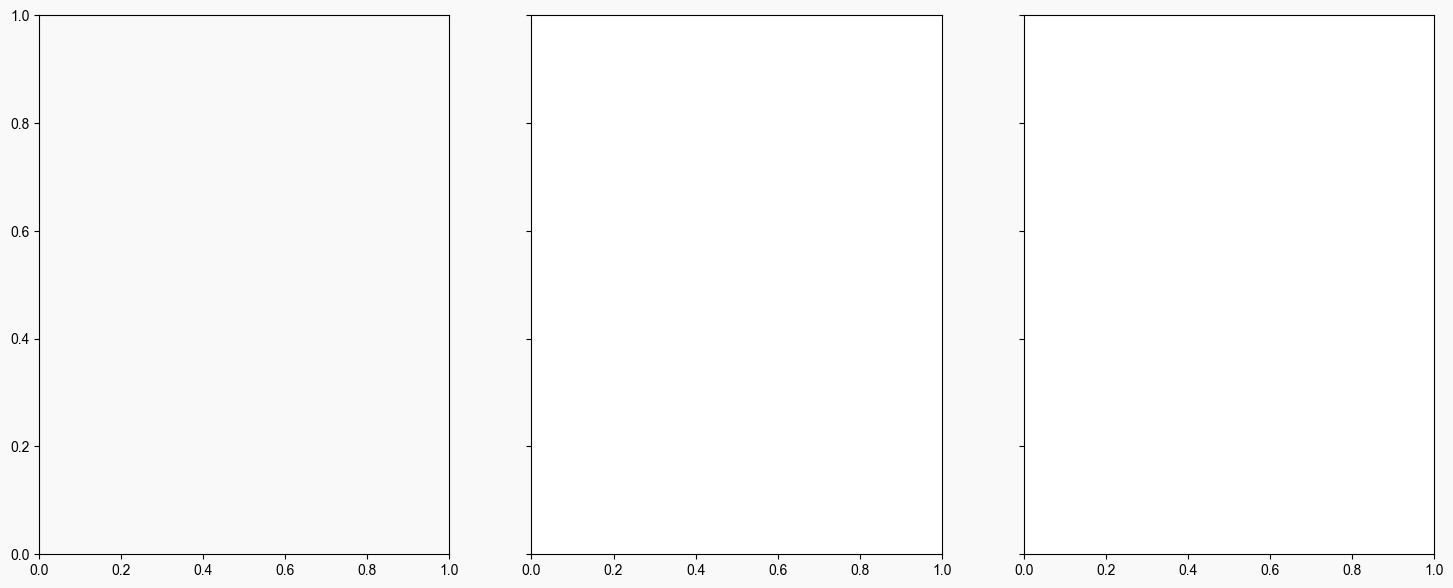

In [13]:
# Définir les paramètres globaux pour la police
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Définir les styles de ligne (tous des traits pleins)
line_styles = ["-"] * 10  # Tous les styles de ligne sont des traits pleins

# Créer une figure avec 3 sous-graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True, facecolor='#f9f9f9')

# Liste des préférences et leurs indices correspondants
preferences = [0, 1, 2]  # Indices pour pref 1, pref 2, pref 4
pref_labels = ['Preference 1', 'Preference 2', 'Preference 3']

# Générer une palette de couleurs pastel
def generate_pastel_colors(n):
    pastel_colors = []
    for i in range(n):
        hue = i / n  # Distribuer les teintes uniformément
        saturation = 0.4  # Saturation légèrement réduite pour des couleurs encore plus pastel
        lightness = 0.85  # Luminosité plus élevée pour des couleurs très claires
        rgb = colorsys.hls_to_rgb(hue, lightness, saturation)
        pastel_colors.append(rgb)
    return pastel_colors

pastel_colors = generate_pastel_colors(n_agents)

for idx, pref in enumerate(preferences):
    ax = axes[idx]
    ax.set_facecolor('#f9f9f9')  # Fond du graphique légèrement plus clair
    for n_agents in range(n_agents):
        # Utiliser la couleur pastel correspondante
        color = pastel_colors[n_agents]
        # Définir la transparence
        alpha = 0.4 + 0.6 * (n_agents / (n_agents+1))  # Safe range: 0.4–1.0

        ax.plot(
            nodes_traje[pref]["expected_mean"][n_agents],
            label=f'Agent {n_agents + 1}' if idx == 0 else "",
            color=color,
            linestyle=line_styles[n_agents % len(line_styles)],
            linewidth=1.5,  # Lignes un peu plus fines
            alpha=alpha
        )
    ax.set_xlabel('Time Step', fontsize=12, fontweight='bold')
    ax.set_title(f'Trajectory of Expected Mean ({pref_labels[idx]})', fontsize=14, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4, color='#e0e0e0', linewidth=0.5)  # Grille très subtile

    # Ajouter une bordure subtile autour de chaque sous-graphique
    for spine in ax.spines.values():
        spine.set_edgecolor('#e0e0e0')  # Couleur de bordure très claire
        spine.set_linewidth(0.8)

# Ajouter une légende commune
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.1, 1), title="Agents", facecolor='#f9f9f9', edgecolor='#e0e0e0')

# Ajouter un titre global
fig.suptitle('Trajectories of Expected Means for Different Preferences', fontsize=16, fontweight='bold', y=1.02)

# Ajuster les marges et l'espacement
plt.tight_layout()
plt.subplots_adjust(top=0.9)  # Ajustement pour le titre global

plt.show()
